In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


class SequentialMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=(128, 64), output_dim=3, dropout=0.2):
        super().__init__() 
        h1, h2 = hidden_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),

            nn.Dropout(p=dropout),

            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(p=dropout),

            nn.Linear(h2, output_dim)
        )

    def forward(self, x):
        return self.net(x)
    

digits = load_digits()
X_train, X_temp, y_train, y_temp = train_test_split(digits.data, digits.target, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

model = SequentialMLP(input_dim=64, hidden_dim=(128, 64), output_dim=10, dropout=0.2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. 모델 성능 최적화 및 결과 분석

## 4-1. 전체 학습 파이프라인 통합 및 조기 종료

- **과적합이란**, 모델이 학습 데이터는 완벽하게 맞추지만, 새로운 데이터에 대해서는 성능이 떨어지는 현상
- **조기 종료**는 과적합을 막는 효과적인 방법중 하나.
    - 일정 기간 동안 검증 손실이 개선되지 않으면, 학습이 충분히 되었다고 판단하고 훈련을 종료
    - 그 후, 가장 성능이 좋았던 시점의 모델을 저장

In [3]:
import copy
# state_dict(): 모델의 파라미터(가중치와 편향)를 딕셔너리 형태로 반환
    # 모델의 파라미터를 쉽게 저장하고 불러오기 위해
# 조기 종료를 구현하려면 가장 성능이 좋았던 모델을
# 따로 저장해야 하기 때문에 state_dict()를 사용
# deepcopy(): 객체를 깊은 복사
    # 모델의 파라미터를 복사할 때 원본 모델에 영향을 주지 않도록 하기 위해 사용
best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float('inf')
patience = 3
counter = 0

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

    # 위 까지는 기존의 학습 루프와 동일

    # 에폭이 끝날 때마다 검증 손실 계산
    # eval() 모드로 전환 (Dropout 같은 기능 비활성화)
    model.eval()
    val_loss = 0.0
    # no_grad() 컨텍스트 매니저: 역전파 과정에서 기울기 계산을 하지 않도록 함
        # 검증 단계에서는 모델의 파라미터를 업데이트하지 않기 때문에
        # 기울기 계산이 필요 없음
    with torch.no_grad():
        for data, target in val_loader:
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item() * data.size(0)  # 배치 손실을 누적

    val_loss /= len(val_loader.dataset)  # 평균 검증 손실 계산
    print(f'Epoch {epoch+1}, Validation Loss: {val_loss:.4f}')

    # 검증 손실이 개선되었는지 확인
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0  # 카운터 초기화
    else:
        counter += 1
        if counter >= patience:
            print("조기 종료: 검증 손실이 개선되지 않음")
            break

Epoch 1, Validation Loss: 1.4324
Epoch 2, Validation Loss: 0.4885
Epoch 3, Validation Loss: 0.2411
Epoch 4, Validation Loss: 0.1640
Epoch 5, Validation Loss: 0.1345
Epoch 6, Validation Loss: 0.1099
Epoch 7, Validation Loss: 0.0973
Epoch 8, Validation Loss: 0.0978
Epoch 9, Validation Loss: 0.0812
Epoch 10, Validation Loss: 0.0765
Epoch 11, Validation Loss: 0.0792
Epoch 12, Validation Loss: 0.0672
Epoch 13, Validation Loss: 0.0654
Epoch 14, Validation Loss: 0.0731
Epoch 15, Validation Loss: 0.0700
Epoch 16, Validation Loss: 0.0680
조기 종료: 검증 손실이 개선되지 않음


## 4-2. 최종 평가 및 결과 분석

- `torch.load`: 가장 성능이 좋았던 모델의 가중치를 다시 불러옴
- **테스트 데이터셋 평가**
- 성능 지표 분석
    1. 분류 리포트(Classification Report)
        - 정확도 뿐만 아니라, 정밀도, 재현율 같은 더 상세한 성능 지표를 통해 모델이 각 숫자 클래스를 얼마나 잘 맞추는지 분석

In [7]:
model.load_state_dict(best_model_wts)
model.eval()
all_preds = []
all_targets = []
with torch.no_grad():
    for data, target in test_loader:
        # 데이터와 타겟을 GPU로 이동
        # if torch.cuda.is_available():
        #     data, target = data.cuda(), target.cuda()
        output = model(data)
        _, preds = torch.max(output, 1)

        # 예측 결과와 실제 타겟을 리스트에 저장
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

from sklearn.metrics import classification_report
print(classification_report(all_targets, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9688    1.0000    0.9841        31
           1     0.9600    1.0000    0.9796        24
           2     1.0000    1.0000    1.0000        27
           3     0.9697    0.9697    0.9697        33
           4     0.9667    1.0000    0.9831        29
           5     0.9630    0.9630    0.9630        27
           6     1.0000    0.9565    0.9778        23
           7     1.0000    1.0000    1.0000        27
           8     1.0000    0.9600    0.9796        25
           9     1.0000    0.9583    0.9787        24

    accuracy                         0.9815       270
   macro avg     0.9828    0.9808    0.9816       270
weighted avg     0.9819    0.9815    0.9815       270



## 4-3. 학습 과정 시각화

- matplotlib을 이용해 에포크별 변화를 그래프로 시각화

Epoch 1, Train Loss: 0.9025, Train Acc: 0.8266, Validation Loss: 0.4447, Validation Acc: 0.9148
Epoch 2, Train Loss: 0.3800, Train Acc: 0.9085, Validation Loss: 0.2428, Validation Acc: 0.9296
Epoch 3, Train Loss: 0.2306, Train Acc: 0.9427, Validation Loss: 0.1748, Validation Acc: 0.9481
Epoch 4, Train Loss: 0.1740, Train Acc: 0.9531, Validation Loss: 0.1473, Validation Acc: 0.9519
Epoch 5, Train Loss: 0.1424, Train Acc: 0.9618, Validation Loss: 0.1169, Validation Acc: 0.9630
Epoch 6, Train Loss: 0.1142, Train Acc: 0.9737, Validation Loss: 0.1147, Validation Acc: 0.9667
Epoch 7, Train Loss: 0.0928, Train Acc: 0.9737, Validation Loss: 0.1035, Validation Acc: 0.9704
Epoch 8, Train Loss: 0.0763, Train Acc: 0.9793, Validation Loss: 0.0983, Validation Acc: 0.9704
Epoch 9, Train Loss: 0.0728, Train Acc: 0.9769, Validation Loss: 0.0981, Validation Acc: 0.9741
Epoch 10, Train Loss: 0.0576, Train Acc: 0.9841, Validation Loss: 0.0892, Validation Acc: 0.9704
Epoch 11, Train Loss: 0.0540, Train Acc

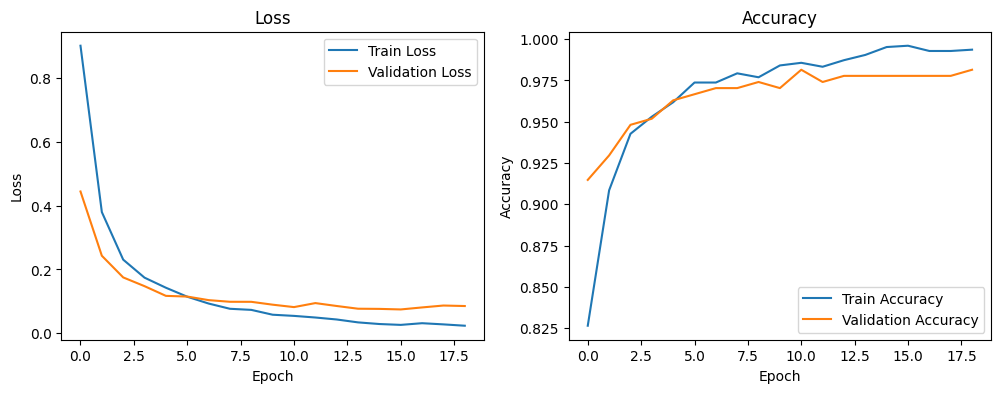

In [4]:
# ## 4-3. 학습 과정 시각화

# - matplotlib을 이용해 에포크별 변화를 그래프로 시각화
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

import copy
# state_dict(): 모델의 파라미터(가중치와 편향)를 딕셔너리 형태로 반환
    # 모델의 파라미터를 쉽게 저장하고 불러오기 위해
# 조기 종료를 구현하려면 가장 성능이 좋았던 모델을
# 따로 저장해야 하기 때문에 state_dict()를 사용
# deepcopy(): 객체를 깊은 복사
    # 모델의 파라미터를 복사할 때 원본 모델에 영향을 주지 않도록 하기 위해 사용
best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float('inf')
patience = 3
counter = 0
# 학습 루프 내에서 손실과 정확도를 기록하는 부분 추가
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}   
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)
        _, preds = torch.max(output, 1)
        correct += (preds == target).sum().item()
        total += target.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in val_loader:
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item() * data.size(0)
            _, preds = torch.max(output, 1)
            correct += (preds == target).sum().item()
            total += target.size(0)

    val_loss /= total
    val_acc = correct / total
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("조기 종료: 검증 손실이 개선되지 않음")
            break

model.load_state_dict(best_model_wts)
model.eval()
plot_training_history(history)